# Utilisation de CNNs pré-entrainés pour extraire des caractéristiques visuelles

In [18]:
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin

import torch
import torchvision.models as models
from torchvision import transforms

import time

In [19]:
# Chargement du modèle pré-entrainé
model = models.squeezenet1_0(pretrained=True)
model = model.float().eval()

# Pré-traitement des données
preprocess = transforms.Compose([
    # transforms.Resize(64),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [20]:
# Encapsulation dans une classe au format Scikit-Learn
class CNNFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, model, preprocess):
        self.model = model
        self.preprocess = preprocess

    def transform(self, X):
        img_tensor = self.preprocess(X)
        with torch.no_grad():
            features = self.model(img_tensor)
        return features.numpy()

    def fit(self, X, y=None):
        return self

### Exemple sur des données simulées

In [21]:
# Exemple sur des données simulées
n = 4
h, w = 64, 64
images = np.random.randn(n, h, w, 3)
images = torch.from_numpy(images).permute(0, 3, 1, 2) # -> (n, 3, h, w)
images = images.float() # float64 --> float32

In [22]:
cnn_model = CNNFeatureExtractor(model, preprocess)
start_time = time.time()
features = cnn_model.transform(images)
end_time = time.time()

print('Représentations de taille {} calculées en {:.3f}s.'.format(features.shape, end_time - start_time))

Représentations de taille (4, 1000) calculées en 0.007s.


### Exemples du cours

In [48]:
from PIL import Image

from skimage.transform import resize
from skimage.color import rgb2gray

from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

In [36]:
# Chargement et création des images

iris = np.array(Image.open('data/iris.jpg'))
ara = np.array(Image.open('data/ara.jpg'))

iris2 = iris[200:1000, 100:]
iris2 = resize(iris2, (600, 600))
iris1 = resize(iris, (600, 600))
ara = resize(ara, (600, 600))

images = (iris1, iris2, ara)

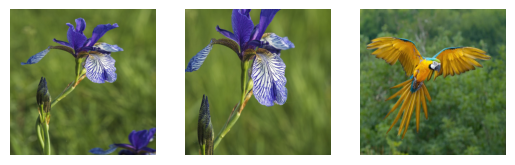

In [37]:
fig, ax = plt.subplots(1, 3)
for img, ax in zip(images, ax):
    ax.imshow(img)
    ax.axis('off')
plt.show()

In [44]:
# Calcul des caractéristiques

features = []
for img in images:
    h, w, _ = img.shape
    img = torch.from_numpy(img).permute(2, 0, 1).view(1, -1, h, w)
    img_feat = cnn_model.transform(img.float())
    features.append(img_feat.reshape(-1))

features = np.stack(features)

In [52]:
flat_imgs = np.stack([img.reshape(-1) for img in images])
img_dist = cdist(np.stack(flat_imgs), np.stack(flat_imgs))
features_dist = cdist(features, features)

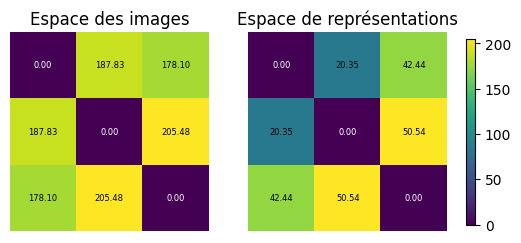

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(6,3))

im0 = ax[0].imshow(img_dist)
im1 = ax[1].imshow(features_dist)

for i in range(img_dist.shape[0]):
    for j in range(img_dist.shape[1]):
        ax[0].text(j, i, f"{img_dist[i, j]:.2f}", ha="center", va="center", color="white" if img_dist[i, j] < 0.5 else "black", fontsize=6)

for i in range(features_dist.shape[0]):
    for j in range(features_dist.shape[1]):
        ax[1].text(j, i, f"{features_dist[i, j]:.2f}", ha="center", va="center", color="white" if features_dist[i, j] < 0.5 else "black", fontsize=6)
        
fig.colorbar(im0, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)

ax[0].axis('off')
ax[1].axis('off')

ax[0].set_title('Espace des images')
ax[1].set_title('Espace de représentations')

plt.show()